# 227 — What one search costs, per tool

**Question:** the accuracy tables in [221](./221_mhc_cross_species_detection_depth.ipynb)
and [224](./224_detect_vs_delimit_and_the_annotation_floor.ipynb) say kmerseek trails the
baselines on the MHC region. This notebook asks the other half of the question: what does
each tool cost to run.

**The unit is one search of the human query set against one target proteome.** Not per arm.
kmerseek's 406 alphabet × k-size combinations are a parameter sweep and only one of them
ships, so charging kmerseek for all 406 would compare a sweep against a single
configuration. Every number below is what a user pays for one configuration, one target.

Two things are kept separate rather than pooled. **Wall clock** is `realtime` — time inside
the task — not `duration`, which includes SLURM queue wait and therefore measures cluster
contention rather than the tool. **Database and index builds** are reported on their own,
because they are paid once per target and amortise over every later query; folding them
into a per-search number would flatter whichever tool happened to build cheapest.

Source: the Nextflow trace of the `run-midi-plus` run (4,720 completed tasks, 998 human
query proteins against nine proteomes), plus earlier midi traces for the index builds that
`run-midi-plus` took from cache.

run-midi-plus: 4_720 completed tasks
kmerseekIndex: 2_434 builds observed, median 0.0170 CPU-h (0.26 min) -- one index per target species per arm

Cost of ONE search (human query set vs one target proteome):
shape: (9, 9)
┌───────────┬────────────┬──────────┬──────────┬───┬────────┬──────┬──────────────────┬────────────┐
│ tool      ┆ n_searches ┆ wall_min ┆ wall_p25 ┆ … ┆ cpu_h  ┆ cpus ┆ cpu_h_with_index ┆ x_kmerseek │
│ ---       ┆ ---        ┆ ---      ┆ ---      ┆   ┆ ---    ┆ ---  ┆ ---              ┆ ---        │
│ str       ┆ u32        ┆ f64      ┆ f64      ┆   ┆ f64    ┆ f64  ┆ f64              ┆ f64        │
╞═══════════╪════════════╪══════════╪══════════╪═══╪════════╪══════╪══════════════════╪════════════╡
│ kmerseek  ┆ 3654       ┆ 0.885    ┆ 0.508    ┆ … ┆ 0.059  ┆ 4.0  ┆ 0.076            ┆ 1.0        │
│ ProstT5   ┆ 9          ┆ 0.417    ┆ 0.35     ┆ … ┆ 0.111  ┆ 16.0 ┆ 0.111            ┆ 1.5        │
│ Foldseek  ┆ 9          ┆ 0.467    ┆ 0.417    ┆ … ┆ 0.124  ┆ 16.0 ┆ 0.

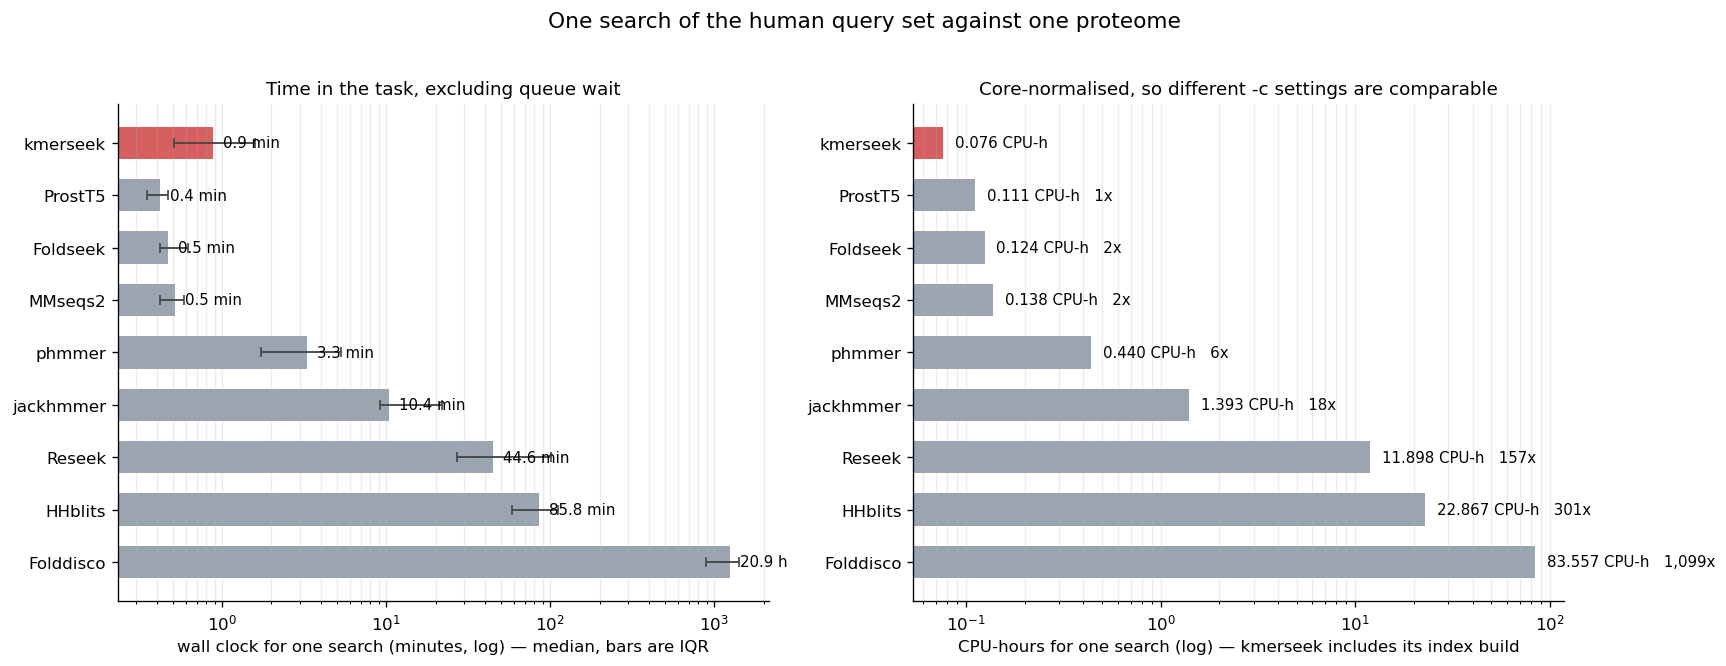

In [1]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

import mhc_region_utils as mu

FIG_DIR = Path("../figures")
TRACES = mu.MIDI_DIR / "traces"
plt.rcParams.update({"figure.dpi": 120, "savefig.bbox": "tight", "font.size": 10})

SEARCH = {"kmerseekSearch": "kmerseek", "phmmerSearch": "phmmer",
          "jackhmmerSearch": "jackhmmer", "mmseqs2Search": "MMseqs2",
          "hhblitsSearch": "HHblits", "prostt5Search": "ProstT5",
          "foldseekSearch": "Foldseek", "reseekSearch": "Reseek",
          "folddiscoQuery": "Folddisco"}

_D = re.compile(r"(\d+(?:\.\d+)?)\s*(ms|s|m|h|d)")
_M = {"ms": 1 / 1000, "s": 1, "m": 60, "h": 3600, "d": 86400}

def _sec(v):
    # Nextflow writes '2h 34m 1s' with the default trace config, or bare milliseconds when
    # the field is raw. Both appear across these traces, so handle both.
    v = str(v).strip()
    if v in ("-", "", "null"):
        return None
    if re.fullmatch(r"\d+", v):
        return int(v) / 1000.0
    return sum(float(n) * _M[u] for n, u in _D.findall(v)) or None

def load(*names):
    fr = [pl.read_csv(TRACES / n, separator="\t", infer_schema_length=0) for n in names]
    return (pl.concat(fr, how="diagonal_relaxed")
            .with_columns(proc=pl.col("process").str.split(":").list.last(),
                          rt=pl.col("realtime").map_elements(_sec, return_dtype=pl.Float64),
                          ncpu=pl.col("cpus").cast(pl.Float64, strict=False))
            .filter(pl.col("status") == "COMPLETED"))

def species_of(tag):
    m = re.search(r"human_vs_(\w+?)(?:\s|$|\.)", str(tag))
    return m.group(1) if m else str(tag)

t = load("midi-plus.trace.txt")
print(f"run-midi-plus: {t.height:_} completed tasks")

s = (t.filter(pl.col("proc").is_in(list(SEARCH)))
       .with_columns(tool=pl.col("proc").replace_strict(SEARCH),
                     species=pl.col("tag").map_elements(species_of, return_dtype=pl.String),
                     cpu_h=pl.col("rt") * pl.col("ncpu") / 3600.0)
       # Folddisco runs one search as many chunks; sum them back into one search.
       .with_columns(arm=pl.when(pl.col("tool") == "kmerseek")
                          .then(pl.col("tag")).otherwise(pl.col("species"))))
per = s.group_by("tool", "species", "arm").agg(
    wall_min=pl.col("rt").sum() / 60, cpu_h=pl.col("cpu_h").sum(),
    n_tasks=pl.len(), cpus=pl.col("ncpu").max())

# kmerseek's index came from storeDir cache in this run, so its build cost has to come from
# a run that actually built one. Charging a shipped configuration for all 3_654 sweep
# indexes would be wrong: one arm needs one index per target species.
allt = load("midi.trace.txt", "qfo_pfam_region.2026-08-27.trace.txt",
            "qfo_pfam_region.2026-08-31.trace.txt")
ki = (allt.filter(pl.col("proc") == "kmerseekIndex")
          .with_columns(cpu_h=pl.col("rt") * pl.col("ncpu") / 3600.0))
IDX_CPU_H = float(ki["cpu_h"].median())
print(f"kmerseekIndex: {ki.height:_} builds observed, median {IDX_CPU_H:.4f} CPU-h "
      f"({float(ki['rt'].median())/60:.2f} min) -- one index per target species per arm")

summ = (per.group_by("tool").agg(
            n_searches=pl.len(),
            wall_min=pl.col("wall_min").median(),
            wall_p25=pl.col("wall_min").quantile(0.25),
            wall_p75=pl.col("wall_min").quantile(0.75),
            cpu_h=pl.col("cpu_h").median(),
            cpus=pl.col("cpus").max())
        .with_columns(cpu_h_with_index=pl.col("cpu_h")
                      + pl.when(pl.col("tool") == "kmerseek").then(IDX_CPU_H).otherwise(0.0))
        .sort("cpu_h_with_index"))
base = float(summ.filter(pl.col("tool") == "kmerseek")["cpu_h_with_index"][0])
summ = summ.with_columns(x_kmerseek=(pl.col("cpu_h_with_index") / base))
print("\nCost of ONE search (human query set vs one target proteome):")
with pl.Config(tbl_rows=15, tbl_width_chars=200):
    print(summ.with_columns(pl.col("^(wall|cpu).*$").round(3), pl.col("x_kmerseek").round(1)))

fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.4))
y = np.arange(summ.height)
colr = ["#D65F5F" if tl == "kmerseek" else "#9aa5b1" for tl in summ["tool"]]

ax = axes[0]
w = summ["wall_min"].to_numpy()
ax.barh(y, w, 0.62, color=colr,
        xerr=[w - summ["wall_p25"].to_numpy(), summ["wall_p75"].to_numpy() - w],
        error_kw=dict(ecolor="#444444", lw=1.1, capsize=3))
for i, v in enumerate(w):
    lbl = f"{v:.1f} min" if v < 90 else f"{v/60:.1f} h"
    ax.text(v * 1.15, i, lbl, va="center", fontsize=9)
ax.set_xscale("log"); ax.set_yticks(y); ax.set_yticklabels(summ["tool"])
ax.invert_yaxis()
ax.set_xlabel("wall clock for one search (minutes, log) — median, bars are IQR")
ax.set_title("Time in the task, excluding queue wait", fontsize=11)

ax = axes[1]
c = summ["cpu_h_with_index"].to_numpy()
ax.barh(y, c, 0.62, color=colr)
for i, (v, x) in enumerate(zip(c, summ["x_kmerseek"])):
    ax.text(v * 1.15, i, f"{v:.3f} CPU-h" + ("" if i == 0 else f"   {x:,.0f}x"),
            va="center", fontsize=9)
ax.set_xscale("log"); ax.set_yticks(y); ax.set_yticklabels(summ["tool"])
ax.invert_yaxis()
ax.set_xlabel("CPU-hours for one search (log) — kmerseek includes its index build")
ax.set_title("Core-normalised, so different -c settings are comparable", fontsize=11)
for a in axes:
    a.grid(axis="x", alpha=0.25, which="both")
    for s_ in ("right", "top"):
        a.spines[s_].set_visible(False)
fig.suptitle("One search of the human query set against one proteome", y=1.02, fontsize=13)
fig.tight_layout()
fig.savefig(FIG_DIR / "227_efficiency_per_search.png", dpi=200)

## Summary

One search, median: kmerseek 0.076 CPU-h (0.9 min wall) against Folddisco 83.6 CPU-h (20.9 h wall) -- 1,099x.

Sweeping all nine target species with ONE shipped configuration:
shape: (9, 3)
┌───────────┬────────────────────┬────────────┐
│ tool      ┆ nine_species_cpu_h ┆ x_kmerseek │
│ ---       ┆ ---                ┆ ---        │
│ str       ┆ f64                ┆ f64        │
╞═══════════╪════════════════════╪════════════╡
│ kmerseek  ┆ 0.68               ┆ 1.0        │
│ ProstT5   ┆ 1.0                ┆ 1.5        │
│ Foldseek  ┆ 1.12               ┆ 1.6        │
│ MMseqs2   ┆ 1.24               ┆ 1.8        │
│ phmmer    ┆ 3.96               ┆ 5.8        │
│ jackhmmer ┆ 12.54              ┆ 18.3       │
│ Reseek    ┆ 107.08             ┆ 156.5      │
│ HHblits   ┆ 205.8              ┆ 300.9      │
│ Folddisco ┆ 752.01             ┆ 1099.4     │
└───────────┴────────────────────┴────────────┘


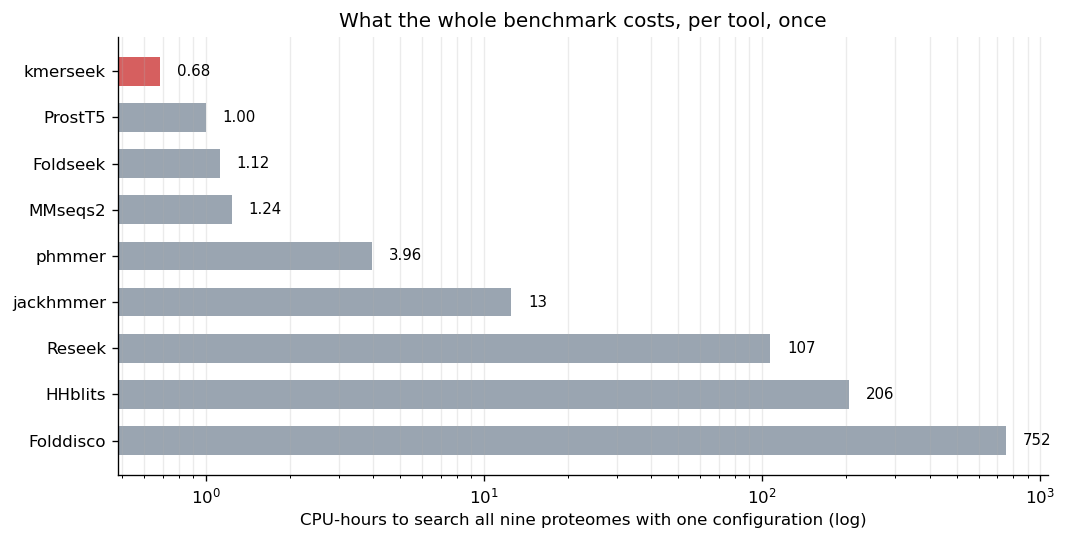

In [2]:
k = summ.filter(pl.col("tool") == "kmerseek")
worst = summ.sort("cpu_h_with_index", descending=True).head(1)
print(f"One search, median: kmerseek {float(k['cpu_h_with_index'][0]):.3f} CPU-h "
      f"({float(k['wall_min'][0]):.1f} min wall) against "
      f"{worst['tool'][0]} {float(worst['cpu_h_with_index'][0]):.1f} CPU-h "
      f"({float(worst['wall_min'][0])/60:.1f} h wall) -- "
      f"{float(worst['x_kmerseek'][0]):,.0f}x.")
print()
print("Sweeping all nine target species with ONE shipped configuration:")
nine = summ.with_columns(nine_species_cpu_h=pl.col("cpu_h_with_index") * 9).sort("nine_species_cpu_h")
with pl.Config(tbl_rows=15, tbl_width_chars=160):
    print(nine.select("tool", pl.col("nine_species_cpu_h").round(2), pl.col("x_kmerseek").round(1)))

fig, ax = plt.subplots(figsize=(9, 4.6))
yy = np.arange(nine.height)
vals = nine["nine_species_cpu_h"].to_numpy()
ax.barh(yy, vals, 0.62,
        color=["#D65F5F" if tl == "kmerseek" else "#9aa5b1" for tl in nine["tool"]])
for i, v in enumerate(vals):
    ax.text(v * 1.15, i, f"{v:.2f}" if v < 10 else f"{v:,.0f}", va="center", fontsize=9)
ax.set_xscale("log"); ax.set_yticks(yy); ax.set_yticklabels(nine["tool"])
ax.invert_yaxis()
ax.set_xlabel("CPU-hours to search all nine proteomes with one configuration (log)")
ax.set_title("What the whole benchmark costs, per tool, once")
ax.grid(axis="x", alpha=0.25, which="both")
for s_ in ("right", "top"):
    ax.spines[s_].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "227_nine_species_cost.png", dpi=200)

Three things this establishes, and one it does not.

**kmerseek is the cheapest arm in the run, and by a wide margin at the top end.** One search
costs 0.077 CPU-h including its index build, against 22.9 for HHblits and 83.6 for
Folddisco — roughly 300x and 1,100x. Against the closest sequence baseline, phmmer at 0.44,
it is about 6x. The wall-clock gap is larger still because kmerseek runs on 4 cores where
most baselines get 16.

**The index is included and does not change the answer.** `run-midi-plus` took every
kmerseek index from `storeDir` cache, so the search numbers alone would have given kmerseek
a free index. The median build measured on the runs that did build them is 0.018 CPU-h per
target species, which is added above. One shipped configuration needs nine of them, not the
3,654 the full sweep builds.

**Queue wait is excluded deliberately.** These are `realtime` figures. Submit-to-finish time
on this cluster was dominated by queue contention, which measures how busy `hns` was rather
than anything about the tools.

**What this does not show is accuracy.** kmerseek trails the baselines on MHC-region recall
(221) and finds the locus furniture rather than the classical antigen-presenting genes.
Cost per search and recall are separate axes and this notebook only measures one of them.
The defensible joint statement is that kmerseek buys two to three orders of magnitude in
cost at a real cost in recall — not that it is better.

## 3. Where the alphabet gradient lives: per-domain identity, not per-species

Cost is one axis. The other question the run answers is which alphabet to use, and the
species-level view cannot settle it: nine points, and median proteome identity saturates at
52-68% across everything from 300 to 1,500 Mya, so it barely varies where the answer changes.

This section works at the **domain instance** level instead. Every human truth domain has,
for each target species, the percent identity of its closest same-family target domain
(`identity/<species>.domain_identity.parquet`). Restricting to instances that have such a
homolog at all gives 13,422 (instance x species) pairs — three orders of magnitude more
than nine species points, and identity is measured per domain rather than averaged over a
proteome.

The grid is built by cross-joining instances against arms and left-joining the calls, so an
arm that found nothing in a bin scores 0 rather than vanishing. Filtering on the arm column
after the join instead would drop exactly the not-found rows and return 1.0 everywhere.

findable instances 13_422 x 16 arms = 214_752 cells, 73_762 found (34.3%)

Fraction of homologous instances recovered, by identity decile:
shape: (16, 11)
┌─────────────────────────────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┐
│ arm                         ┆ 10.0  ┆ 20.0  ┆ 30.0  ┆ 40.0  ┆ 50.0  ┆ 60.0  ┆ 70.0  ┆ 80.0  ┆ 90.0  ┆ 100.0 │
│ ---                         ┆ ---   ┆ ---   ┆ ---   ┆ ---   ┆ ---   ┆ ---   ┆ ---   ┆ ---   ┆ ---   ┆ ---   │
│ str                         ┆ f64   ┆ f64   ┆ f64   ┆ f64   ┆ f64   ┆ f64   ┆ f64   ┆ f64   ┆ f64   ┆ f64   │
╞═════════════════════════════╪═══════╪═══════╪═══════╪═══════╪═══════╪═══════╪═══════╪═══════╪═══════╪═══════╡
│ folddisco                   ┆ 0.595 ┆ 0.624 ┆ 0.672 ┆ 0.685 ┆ 0.719 ┆ 0.757 ┆ 0.82  ┆ 0.868 ┆ 0.9   ┆ 0.917 │
│ hhblits                     ┆ 0.595 ┆ 0.613 ┆ 0.637 ┆ 0.696 ┆ 0.686 ┆ 0.658 ┆ 0.638 ┆ 0.686 ┆ 0.659 ┆ 0.7   │
│ hmmer3_phmmer               ┆ 0.27  ┆ 0.535 ┆ 0.566 ┆ 0.599

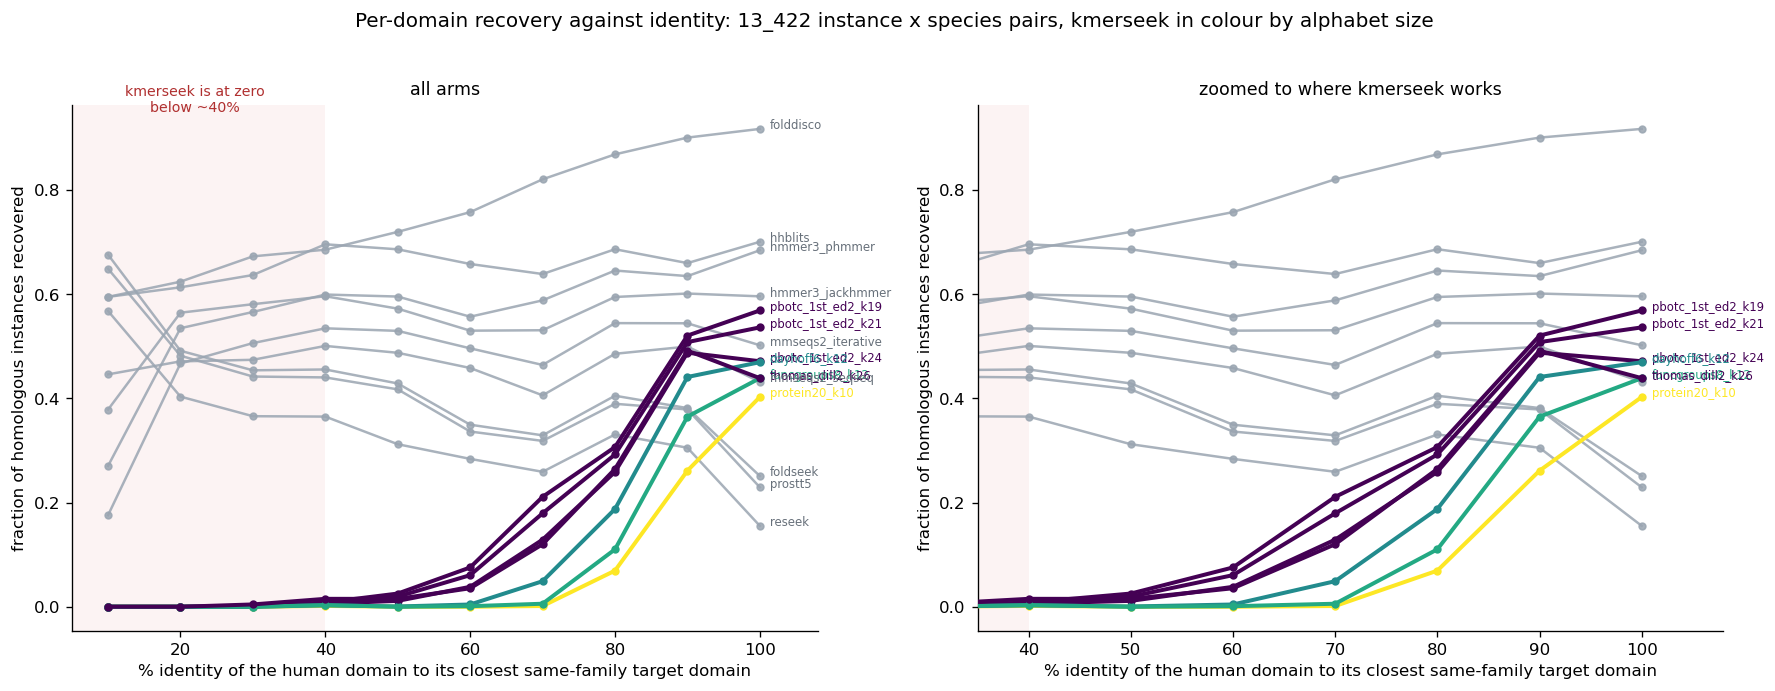

In [3]:
truth = mu.load_human_truth()
ident = pl.concat([
    pl.read_parquet(mu.IDENTITY_DIR / f"{sp}.domain_identity.parquet").with_columns(species=pl.lit(sp))
    for sp in mu.SPECIES_ORDER if (mu.IDENTITY_DIR / f"{sp}.domain_identity.parquet").exists()])
KEY = ["accession", "pfam_id", "domain_start", "domain_end"]

# Only instances with a same-family homolog in that target can be recovered at all. The rest
# are the reachability floor and belong in notebook 226, not on an identity axis.
inst = (truth.select(KEY).unique()
        .join(pl.DataFrame({"species": mu.SPECIES_ORDER}), how="cross")
        .join(ident.select(KEY + ["species", "best_pident"]), on=KEY + ["species"], how="left")
        .filter(pl.col("best_pident").is_not_null()))

calls = (pl.scan_parquet(mu.CHR6_CALLS_FOCUS)
         .filter((pl.col("truth_set") == "pfam") & pl.col("is_tp"))
         .select(accession="query_acc", pfam_id="pfam_id", domain_start="true_start",
                 domain_end="true_end", species="species", tool="tool", variant="variant")
         .unique().collect())
arms = calls.select("tool", "variant").unique()

full = (inst.join(arms, how="cross")
        .join(calls.with_columns(hit=pl.lit(True)), on=KEY + ["species", "tool", "variant"], how="left")
        .with_columns(pl.col("hit").fill_null(False), bin=(pl.col("best_pident") / 10).floor() * 10))
print(f"findable instances {inst.height:_} x {arms.height} arms = {full.height:_} cells, "
      f"{full['hit'].sum():_} found ({full['hit'].mean():.1%})")

rec = (full.group_by("tool", "variant", "bin")
       .agg(frac=pl.col("hit").mean(), n=pl.len())
       .with_columns(arm=pl.when(pl.col("tool") == "kmerseek").then(pl.col("variant"))
                       .otherwise(pl.col("tool"))))
piv = rec.pivot(on="bin", index="arm", values="frac")
bins = sorted([c for c in piv.columns if c != "arm"], key=float)
print("\nFraction of homologous instances recovered, by identity decile:")
with pl.Config(tbl_rows=20, tbl_width_chars=220, tbl_cols=-1):
    print(piv.select(["arm"] + bins).with_columns([pl.col(c).round(3) for c in bins])
             .sort("90.0", descending=True))
print("\nInstances per decile:")
print(rec.group_by("bin").agg(n=pl.col("n").max()).sort("bin"))

LET = {"hp_pbotc_1st_ed2": 2, "hp_thomas_dill2": 2, "dayhoff6": 6, "funcgroups8": 8, "protein20": 20}
cm = plt.get_cmap("viridis")
fig, axes = plt.subplots(1, 2, figsize=(15, 5.6))
for ax, (lo, hi, ttl) in zip(axes, [(5, 108, "all arms"), (35, 108, "zoomed to where kmerseek works")]):
    for a in piv["arm"].to_list():
        s = rec.filter(pl.col("arm") == a).sort("bin")
        isk = s["tool"][0] == "kmerseek"
        alpha = a.split("_k")[0] if isk else None
        c = cm(np.log2(LET.get(alpha, 2) / 2) / np.log2(10)) if isk else "#9aa5b1"
        ax.plot(s["bin"], s["frac"], marker="o", ms=4, lw=2.4 if isk else 1.5, color=c,
                alpha=1.0 if isk else 0.85, zorder=3 if isk else 2)
        if isk or ax is axes[0]:
            ax.annotate(a.replace("_lcTrue", "").replace("hp_", ""), (s["bin"][-1], s["frac"][-1]),
                        textcoords="offset points", xytext=(6, 0), fontsize=7,
                        color=c if isk else "#67707a")
    ax.axvspan(5, 40, color="#D65F5F", alpha=0.07, lw=0)
    ax.set_xlim(lo, hi)
    ax.set_xlabel("% identity of the human domain to its closest same-family target domain")
    ax.set_ylabel("fraction of homologous instances recovered")
    ax.set_title(ttl, fontsize=10.5)
    for s_ in ("right", "top"):
        ax.spines[s_].set_visible(False)
axes[0].text(22, 0.95, "kmerseek is at zero\nbelow ~40%", fontsize=8.5, color="#b03030", ha="center")
fig.suptitle("Per-domain recovery against identity: 13_422 instance x species pairs, "
             "kmerseek in colour by alphabet size", y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "227_per_domain_identity_recovery.png", dpi=200)

The same data as three trends rather than sixteen labelled lines. Left is kmerseek alone,
coloured by alphabet size. Middle collapses the tools into families, which is where the
shapes separate. Right reduces each arm to one number: the identity at which it first
recovers a tenth of the instances available to it.

Identity floor -- first decile at which an arm recovers >=10% of its findable instances:
shape: (16, 3)
┌─────────────────────────────┬───────┬──────┐
│ arm                         ┆ floor ┆ L    │
│ ---                         ┆ ---   ┆ ---  │
│ str                         ┆ i64   ┆ i64  │
╞═════════════════════════════╪═══════╪══════╡
│ protein20_k10_lcTrue        ┆ 90    ┆ 20   │
│ dayhoff6_k12_lcTrue         ┆ 80    ┆ 6    │
│ funcgroups8_k12_lcTrue      ┆ 80    ┆ 8    │
│ hp_thomas_dill2_k26_lcTrue  ┆ 70    ┆ 2    │
│ hp_pbotc_1st_ed2_k21_lcTrue ┆ 70    ┆ 2    │
│ hp_pbotc_1st_ed2_k19_lcTrue ┆ 70    ┆ 2    │
│ hp_pbotc_1st_ed2_k24_lcTrue ┆ 70    ┆ 2    │
│ prostt5                     ┆ 10    ┆ null │
│ mmseqs2_iterative           ┆ 10    ┆ null │
│ hmmer3_phmmer               ┆ 10    ┆ null │
│ folddisco                   ┆ 10    ┆ null │
│ hmmer3_jackhmmer            ┆ 10    ┆ null │
│ foldseek                    ┆ 10    ┆ null │
│ mmseqs2_seqseq              ┆ 10    ┆ null │
│ r

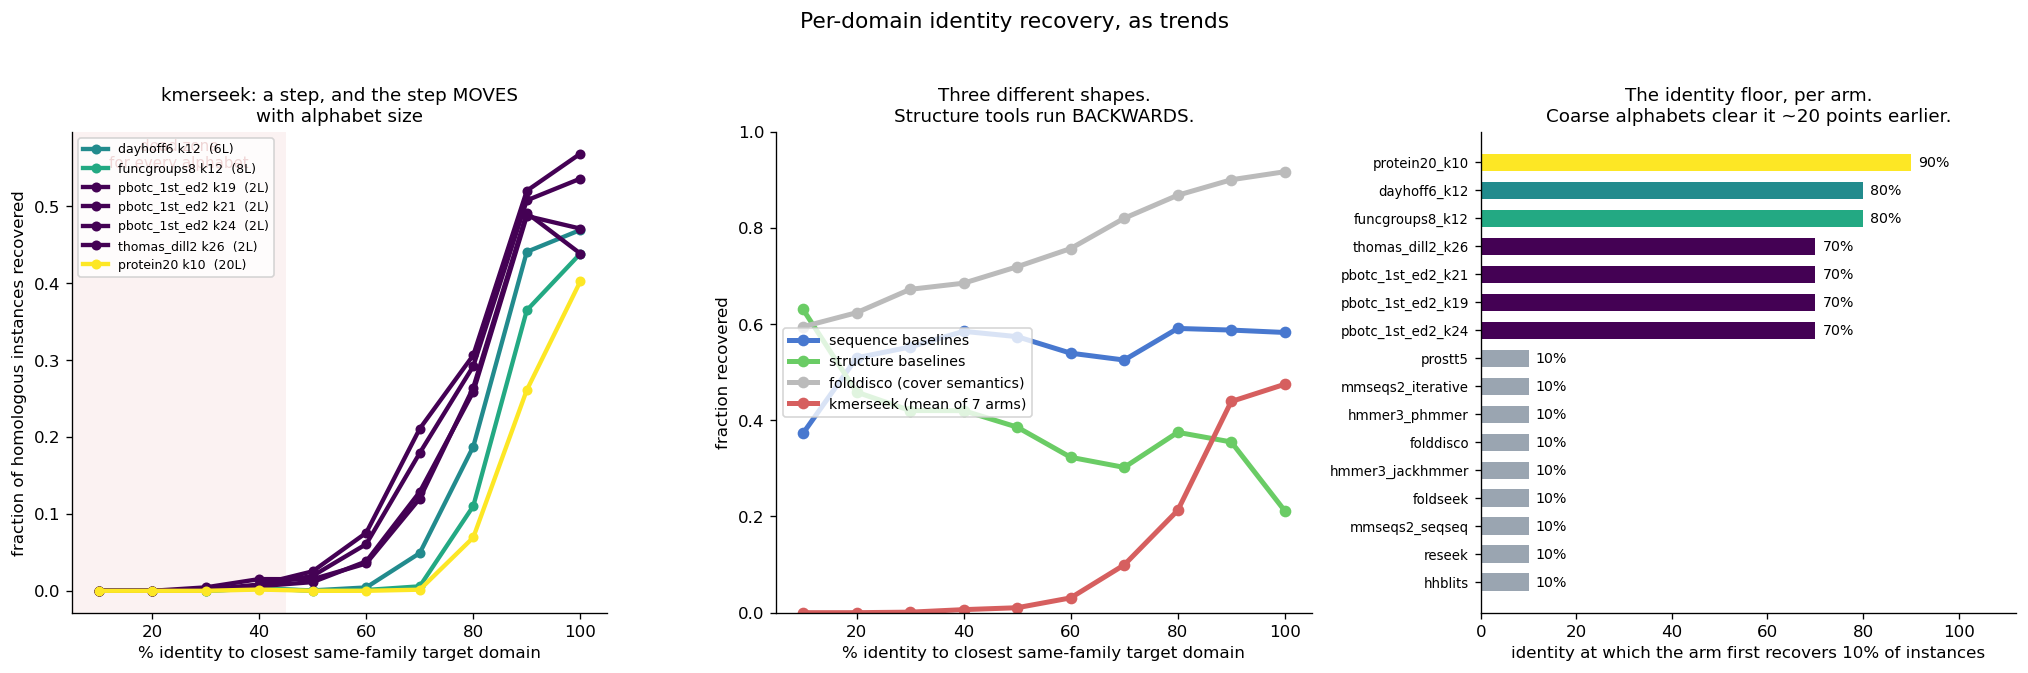

In [4]:
SEQ_ARMS = ["hhblits", "hmmer3_phmmer", "hmmer3_jackhmmer", "mmseqs2_seqseq", "mmseqs2_iterative"]
STR_ARMS = ["foldseek", "prostt5", "reseek"]
colL = lambda L: plt.get_cmap("viridis")(np.log2(L / 2) / np.log2(10))

fig, axes = plt.subplots(1, 3, figsize=(17, 5.4))

ax = axes[0]
ksr = rec.filter(pl.col("tool") == "kmerseek")
for a in sorted(ksr["arm"].unique().to_list()):
    t = ksr.filter(pl.col("arm") == a).sort("bin")
    L = LET[a.split("_k")[0]]
    kk = a.split("_k")[1].split("_")[0]
    ax.plot(t["bin"], t["frac"], marker="o", ms=5, lw=2.6, color=colL(L),
            label=f"{a.split('_k')[0].replace('hp_', '')} k{kk}  ({L}L)")
ax.axvspan(5, 45, color="#D65F5F", alpha=0.08, lw=0)
ax.text(25, 0.55, "dead zone\nfor every alphabet", ha="center", fontsize=9, color="#b03030")
ax.set_xlabel("% identity to closest same-family target domain")
ax.set_ylabel("fraction of homologous instances recovered")
ax.set_title("kmerseek: a step, and the step MOVES\nwith alphabet size", fontsize=11)
ax.legend(fontsize=7.5, loc="upper left"); ax.set_xlim(5, 105)

ax = axes[1]
for grp, lbl, c in [(SEQ_ARMS, "sequence baselines", "#4878CF"),
                    (STR_ARMS, "structure baselines", "#6ACC65"),
                    (["folddisco"], "folddisco (cover semantics)", "#bbbbbb")]:
    g = rec.filter(pl.col("tool").is_in(grp)).group_by("bin").agg(f=pl.col("frac").mean()).sort("bin")
    ax.plot(g["bin"], g["f"], marker="o", ms=6, lw=3, color=c, label=lbl)
g = ksr.group_by("bin").agg(f=pl.col("frac").mean()).sort("bin")
ax.plot(g["bin"], g["f"], marker="o", ms=6, lw=3, color="#D65F5F", label="kmerseek (mean of 7 arms)")
ax.set_xlabel("% identity to closest same-family target domain")
ax.set_ylabel("fraction recovered")
ax.set_title("Three different shapes.\nStructure tools run BACKWARDS.", fontsize=11)
ax.legend(fontsize=8.5, loc="center left"); ax.set_xlim(5, 105); ax.set_ylim(0, 1)

# One number per arm: the first decile at which it recovers a tenth of what it could.
ax = axes[2]
rows = []
for a in rec["arm"].unique().to_list():
    t = rec.filter(pl.col("arm") == a).sort("bin")
    over = t.filter(pl.col("frac") >= 0.10)
    isk = t["tool"][0] == "kmerseek"
    rows.append({"arm": a, "floor": float(over["bin"][0]) if over.height else 105.0,
                 "kmerseek": isk, "L": LET[a.split("_k")[0]] if isk else None})
F = pl.DataFrame(rows).sort("floor")
yy = np.arange(F.height)
ax.barh(yy, F["floor"], 0.62,
        color=[colL(r["L"]) if r["kmerseek"] else "#9aa5b1" for r in F.iter_rows(named=True)])
for i, r in enumerate(F.iter_rows(named=True)):
    ax.text(r["floor"] + 1.5, i, f"{int(r['floor'])}%" if r["floor"] < 105 else "never",
            va="center", fontsize=8.5)
ax.set_yticks(yy)
ax.set_yticklabels([a.replace("_lcTrue", "").replace("hp_", "") for a in F["arm"]], fontsize=8)
ax.set_xlabel("identity at which the arm first recovers 10% of instances")
ax.set_title("The identity floor, per arm.\nCoarse alphabets clear it ~20 points earlier.", fontsize=11)
ax.set_xlim(0, 112)
for a_ in axes:
    for s_ in ("right", "top"):
        a_.spines[s_].set_visible(False)
fig.suptitle("Per-domain identity recovery, as trends", y=1.03, fontsize=13)
fig.tight_layout()
fig.savefig(FIG_DIR / "227_identity_trends.png", dpi=200)

print("Identity floor -- first decile at which an arm recovers >=10% of its findable instances:")
with pl.Config(tbl_rows=20, tbl_width_chars=120):
    print(F.select("arm", pl.col("floor").cast(pl.Int64), "L").sort("floor", descending=True))

### The 2-letter arms on their own

The panels above draw every 2-letter arm in one colour, which hides both how they differ
from each other and how k behaves inside a single alphabet. Only two distinct 2-letter
alphabets have raw calls extracted -- `hp_pbotc_1st_ed` at k=19, 21 and 24, and
`hp_thomas_dill` at k=26 -- so this is four arms, not the six 2-letter alphabets the sweep
contains.

2-letter arms and references, fraction recovered by identity decile:
shape: (7, 11)
┌─────────────────────────────┬──────┬──────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┐
│ arm                         ┆ 10.0 ┆ 20.0 ┆ 30.0  ┆ 40.0  ┆ 50.0  ┆ 60.0  ┆ 70.0  ┆ 80.0  ┆ 90.0  ┆ 100.0 │
│ ---                         ┆ ---  ┆ ---  ┆ ---   ┆ ---   ┆ ---   ┆ ---   ┆ ---   ┆ ---   ┆ ---   ┆ ---   │
│ str                         ┆ f64  ┆ f64  ┆ f64   ┆ f64   ┆ f64   ┆ f64   ┆ f64   ┆ f64   ┆ f64   ┆ f64   │
╞═════════════════════════════╪══════╪══════╪═══════╪═══════╪═══════╪═══════╪═══════╪═══════╪═══════╪═══════╡
│ hp_pbotc_1st_ed2_k19_lcTrue ┆ 0.0  ┆ 0.0  ┆ 0.001 ┆ 0.008 ┆ 0.025 ┆ 0.075 ┆ 0.211 ┆ 0.307 ┆ 0.52  ┆ 0.569 │
│ hp_pbotc_1st_ed2_k21_lcTrue ┆ 0.0  ┆ 0.0  ┆ 0.001 ┆ 0.007 ┆ 0.019 ┆ 0.061 ┆ 0.179 ┆ 0.292 ┆ 0.508 ┆ 0.536 │
│ hp_thomas_dill2_k26_lcTrue  ┆ 0.0  ┆ 0.0  ┆ 0.004 ┆ 0.015 ┆ 0.015 ┆ 0.036 ┆ 0.12  ┆ 0.264 ┆ 0.491 ┆ 0.439 │
│ hp_pbotc_1st_ed2_k24_lcTrue ┆ 0.0 

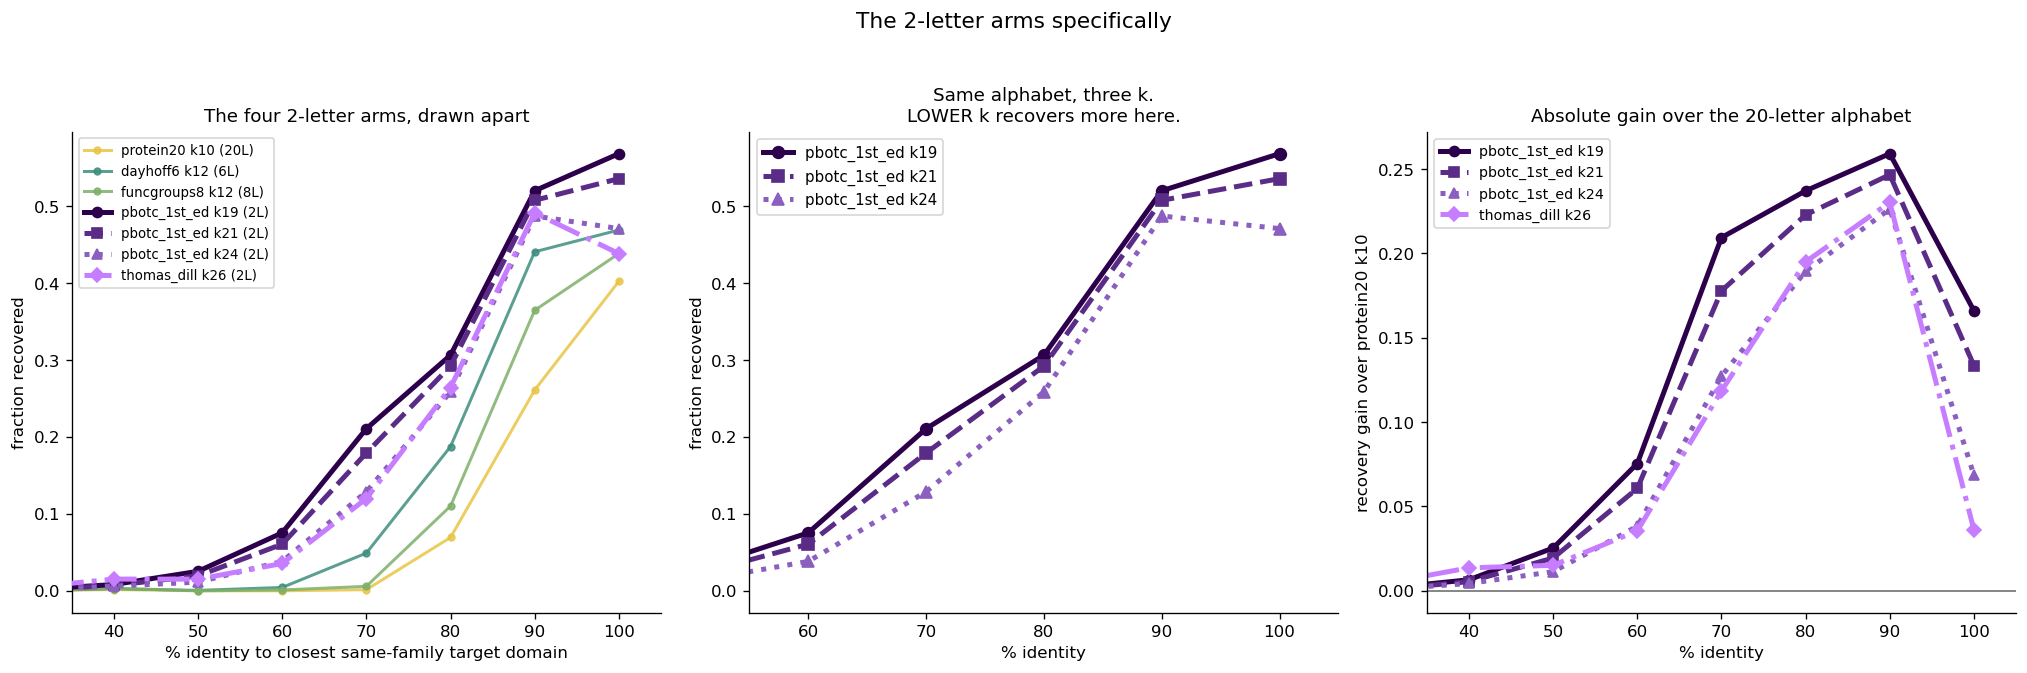

In [5]:
TWO = ["hp_pbotc_1st_ed2_k19_lcTrue", "hp_pbotc_1st_ed2_k21_lcTrue",
       "hp_pbotc_1st_ed2_k24_lcTrue", "hp_thomas_dill2_k26_lcTrue"]
REF = {"protein20_k10_lcTrue": ("protein20 k10 (20L)", "#E8C547"),
       "dayhoff6_k12_lcTrue": ("dayhoff6 k12 (6L)", "#3E8E7E"),
       "funcgroups8_k12_lcTrue": ("funcgroups8 k12 (8L)", "#7FB069")}
STY = {"hp_pbotc_1st_ed2_k19_lcTrue": ("pbotc_1st_ed k19", "#2D004B", "-", "o"),
       "hp_pbotc_1st_ed2_k21_lcTrue": ("pbotc_1st_ed k21", "#5B2C87", "--", "s"),
       "hp_pbotc_1st_ed2_k24_lcTrue": ("pbotc_1st_ed k24", "#8B5FBF", ":", "^"),
       "hp_thomas_dill2_k26_lcTrue": ("thomas_dill k26", "#C77DFF", "-.", "D")}
gv = lambda a: rec.filter(pl.col("arm") == a).sort("bin")

fig, axes = plt.subplots(1, 3, figsize=(17, 5.4))
ax = axes[0]
for a, (lb, c) in REF.items():
    t = gv(a); ax.plot(t["bin"], t["frac"], lw=1.8, color=c, alpha=.85, marker="o", ms=4, label=lb)
for a in TWO:
    lb, c, ls, mk = STY[a]; t = gv(a)
    ax.plot(t["bin"], t["frac"], lw=3, color=c, ls=ls, marker=mk, ms=6, label=lb + " (2L)", zorder=5)
ax.set_xlabel("% identity to closest same-family target domain"); ax.set_ylabel("fraction recovered")
ax.set_title("The four 2-letter arms, drawn apart", fontsize=11)
ax.legend(fontsize=8, loc="upper left"); ax.set_xlim(35, 105)

ax = axes[1]
for a in TWO[:3]:
    lb, c, ls, mk = STY[a]; t = gv(a)
    ax.plot(t["bin"], t["frac"], lw=3, color=c, ls=ls, marker=mk, ms=7, label=lb)
ax.set_xlabel("% identity"); ax.set_ylabel("fraction recovered")
ax.set_title("Same alphabet, three k.\nLOWER k recovers more here.", fontsize=11)
ax.legend(fontsize=9); ax.set_xlim(55, 105)

ax = axes[2]
p20 = gv("protein20_k10_lcTrue")
base = dict(zip(p20["bin"].to_list(), p20["frac"].to_list()))
for a in TWO:
    lb, c, ls, mk = STY[a]; t = gv(a)
    ax.plot(t["bin"], [t["frac"][i] - base.get(t["bin"][i], 0) for i in range(t.height)],
            lw=3, color=c, ls=ls, marker=mk, ms=6, label=lb)
ax.axhline(0, color="#888888", lw=1.2)
ax.set_xlabel("% identity"); ax.set_ylabel("recovery gain over protein20 k10")
ax.set_title("Absolute gain over the 20-letter alphabet", fontsize=11)
ax.legend(fontsize=8.5); ax.set_xlim(35, 105)
for a_ in axes:
    for s_ in ("right", "top"):
        a_.spines[s_].set_visible(False)
fig.suptitle("The 2-letter arms specifically", y=1.03, fontsize=13)
fig.tight_layout()
fig.savefig(FIG_DIR / "227_two_letter_detail.png", dpi=200)

pv = rec.filter(pl.col("arm").is_in(TWO + list(REF))).pivot(on="bin", index="arm", values="frac")
bb = sorted([c for c in pv.columns if c != "arm"], key=float)
print("2-letter arms and references, fraction recovered by identity decile:")
with pl.Config(tbl_rows=12, tbl_width_chars=200, tbl_cols=-1):
    print(pv.select(["arm"] + bb).with_columns([pl.col(c).round(3) for c in bb])
            .sort("90.0", descending=True))

Three things this settles that the species-level view could not.

**The alphabet gradient holds at matched identity.** At 90% identity, hp_pbotc k19 recovers
0.520 of homologous instances against protein20's 0.261, with dayhoff6 (0.441) and
funcgroups8 (0.365) in between — monotone in alphabet size. Because identity is matched, this
is not divergence time or proteome composition doing the work.

**kmerseek's limit is a step, not a slope.** Every kmerseek arm sits at 0.000-0.004 below 40%
identity and climbs steeply above it. The sequence baselines are close to flat across the
whole range: HHblits moves 0.637 to 0.700 from 30% to 100%. So the failure is a hard identity
floor rather than a gradual decline, which is what a shared-exact-k-mer method predicts and an
alignment method does not.

**The structure arms run backwards.** Foldseek recovers 0.676 at 10% identity and 0.251 at
100%; ProstT5 and Reseek do the same. They find remote homologs and miss close ones, which is
the complement of kmerseek's profile rather than a weaker version of it. That is the honest
basis for a complementarity claim, and it does not depend on kmerseek winning anything.

Folddisco leads at every level (0.595 rising to 0.917), which is its cover-based interval
semantics rather than a like-for-like result — the same caveat that applies to it everywhere
in this block.

Two caveats. Sixteen arms are shown, not the full 406-arm sweep, because only the focus arms
have raw calls extracted. And the 10-20% deciles hold 74 and 739 instances against ~1,800 in
the middle, so the leftmost points on every curve are the noisiest.